<a href="https://colab.research.google.com/github/ferdinano/Aprendizaje_automatico_2026/blob/main/Clase%204/%20Erjercio_clase_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 1
Es importante que realices todas las actividades, estas te permitirán saber como vas avanzando y podrás reflexionar sobre la teoría si te queda alguna duda de cómo hacer esta actividad por favor consultanos en el campus.

El objetivo de esta actividad es encontrar un dataset de tu interés que contenga como variable objetivo una variable continua y aplicar la regresión lineal para intentar predecirla a partir de las demás variables predictoras.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score

In [3]:
# cargar datos de un csv
df = pd.read_csv("/content/diabetes_data.csv")
df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:

# tomo solo los datos de Age y Glucose
df_elegido = df[['Age', 'BMI']]
# Mostramos las primeras filas para verificar
print(df_elegido.head())

print(df_elegido.corr())
#df_simple.corr()

   Age   BMI
0   50  33.6
1   31  26.6
2   32  23.3
3   21  28.1
4   33  43.1
          Age       BMI
Age  1.000000  0.036242
BMI  0.036242  1.000000


Descripcion estadistica
              Age         BMI
count  768.000000  768.000000
mean    33.240885   31.992578
std     11.760232    7.884160
min     21.000000    0.000000
25%     24.000000   27.300000
50%     29.000000   32.000000
75%     41.000000   36.600000
max     81.000000   67.100000
Grafico


Text(0, 0.5, 'IMC')

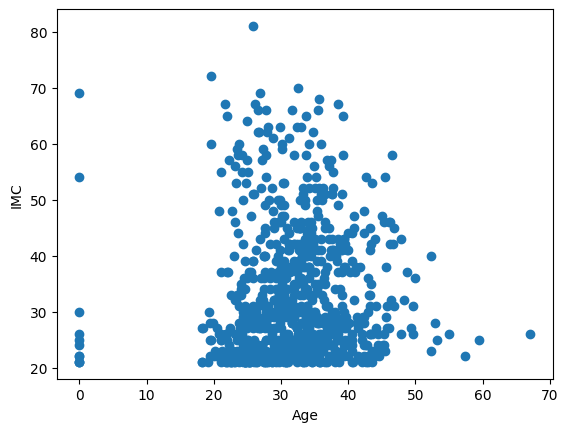

In [8]:
print("Descripcion estadistica")
print(df_elegido.describe())
print("Grafico")
plt.scatter(df_elegido.BMI, df_elegido.Age)
plt.xlabel("Age")
plt.ylabel("IMC")


In [9]:
X = df_elegido[['Age']]
y = df_elegido['BMI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred_simple = model_simple.predict(X_test)

Intercepto: 31.88478783786934
Coeficiente: [0.0029963]

Evaluación del modelo (Regresión Simple):
MAE: 6.051193000718613
MSE: 70.99807860058112
R²: 0.0012290314419062254
Varianza explicada: 0.001252502331580474


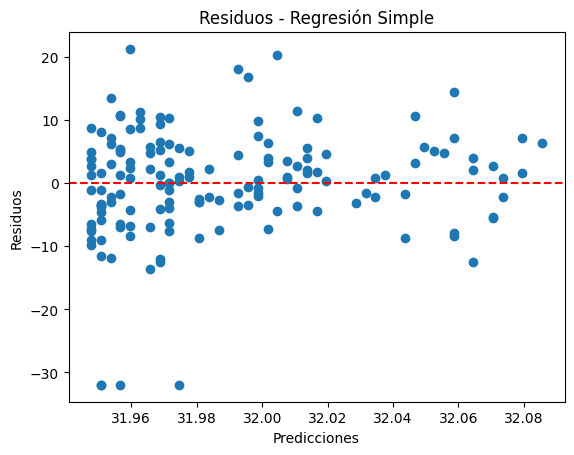

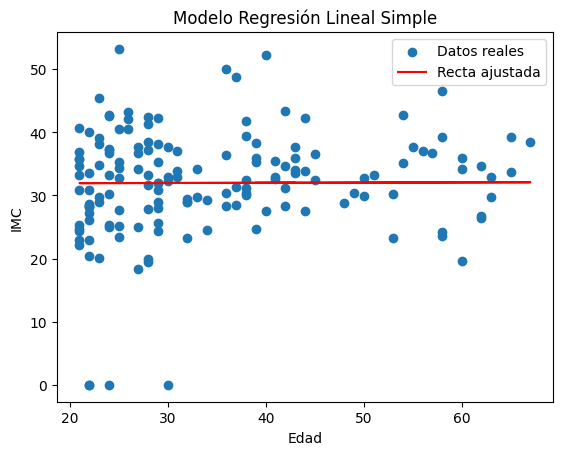

In [10]:

print("Intercepto:", model_simple.intercept_)
print("Coeficiente:", model_simple.coef_)

print("\nEvaluación del modelo (Regresión Simple):")
print("MAE:", mean_absolute_error(y_test, y_pred_simple))
print("MSE:", mean_squared_error(y_test, y_pred_simple))
print("R²:", r2_score(y_test, y_pred_simple))
print("Varianza explicada:", explained_variance_score(y_test, y_pred_simple))

residuos = y_test - y_pred_simple
plt.scatter(y_pred_simple, residuos)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos - Regresión Simple")
plt.show()

plt.scatter(X_test, y_test, label="Datos reales")
plt.plot(X_test, y_pred_simple, color='red', label="Recta ajustada")
plt.xlabel("Edad")
plt.ylabel("IMC")
plt.legend()
plt.title("Modelo Regresión Lineal Simple")
plt.show()


Segun las variables elegidas para este proyecto que es El indice de masa corporal (IMC) y la edad, donde el IMC puede cambiar con la edad:
Los resultados muestran que la edad no tiene una relación lineal significativa con el IMC. El modelo presenta un coeficiente cercano a cero y métricas de desempeño muy bajas, como el R2 es 0,12 % que es cercano a 0, lo que indica que no es adecuado para predecir el IMC, tambien se puede observar que cuando se tiene 0 años no se puede interpretar el IMC. es por eso que debemos revisar el modelo y tomar otras variables.

# Actividad 2
Te proponemos entonces que realices ahora la siguiente actividad con los conceptos leídos anteriormente.

Para esta actividad se ha creado un archivo usuarios_win_mac_lin.csv con datos de entrada a modo de ejemplo para clasificar si el usuario que visita un sitio web usa como sistema operativo Windows, Macintosh o Linux.

Nuestra información de entrada son 4 características que se tomó de una web que utiliza Google Analytics y son:

●      Duración de la visita en Segundos

●      Cantidad de Páginas Vistas durante la Sesión

●      Cantidad de Acciones del usuario (click, scroll, uso de checkbox, sliders,etc)

●      Suma del Valor de las acciones (cada acción lleva asociada una valoración de importancia)

Como la salida es discreta, asignaremos los siguientes valores a las etiquetas:

0 – Windows

1 – Macintosh

2 -Linux

Tu tarea es crear una Jupyter Notebook Regresion_logistica.ipynb que permita predecir qué sistema operativo utiliza un usuario según los datos de entrada.

In [24]:
# Importamos las librerias necesarias buscadas en intenet
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [11]:
# Leemos los datos CSV
df = pd.read_csv("/content/usuarios_win_mac_lin.csv")

df.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


In [12]:
# Exploramos los datos
print(df.shape)
print(df.info())
print(df.describe())

# Ver distribución de la clase
print(df['clase'].value_counts())

(170, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB
None
         duracion     paginas    acciones       valor       clase
count  170.000000  170.000000  170.000000  170.000000  170.000000
mean   111.075729    2.041176    8.723529   32.676471    0.752941
std    202.453200    1.500911    9.136054   44.751993    0.841327
min      1.000000    1.000000    1.000000    1.000000    0.000000
25%     11.000000    1.000000    3.000000    8.000000    0.000000
50%     13.000000    2.000000    6.000000   20.000000    0.000000
75%    108.000000    2.000000   10.000000   36.000000    2.000000
max    898.000000    9.000000  

In [13]:
# separamos las Variables independientes y dependientes
X = df.drop("clase", axis=1)
y = df["clase"]

In [48]:
# Dividimos en entrenamoiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
#print(X_train.shape)
print(X_test)
#print(y_train.shape)
print(y_test)

     duracion  paginas  acciones  valor
4     109.000        2         6     12
72    530.000        3        12     24
122    12.000        1         2      2
128    12.000        1         1      1
2      57.000        2         4      4
155    12.000        1         1      2
51      7.000        1         7     28
86     15.000        2         2      4
111    12.000        1         3      3
107    13.000        1         6     18
98     12.000        1         6     48
112    12.000        1         1      1
78      1.169        4        12     24
147    11.000        1         5     15
8     170.000        2         4      8
164    13.000        1         4      8
0       7.000        2         4      8
69    293.000        4         8     24
13    798.000        5        15     15
50      2.000        2        20    120
144    12.000        1         8     24
17     21.000        2         4     12
46    674.000        3        18     72
45    278.000        2         4     28


In [32]:
# Creamos y entrenamos al modelo
modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [33]:
# Predicciones
y_pred = modelo.predict(X_test)

In [36]:
# Evaluacion del modelo
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7352941176470589

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.75      0.71      0.73        17
           1       1.00      0.50      0.67         8
           2       0.64      1.00      0.78         9

    accuracy                           0.74        34
   macro avg       0.80      0.74      0.73        34
weighted avg       0.78      0.74      0.73        34



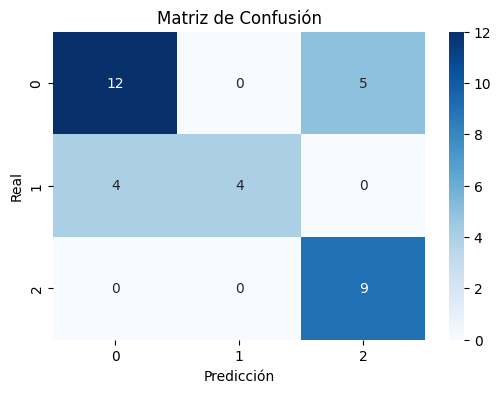

In [37]:
# Usamos la matriz de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

In [49]:
# Probamos con nuevos datos
# Ejemplo: nuevo usuario
nuevo_usuario = pd.DataFrame({
    "duracion": [13],
    "paginas": [1],
    "acciones": [6],
    "valor": [18]
})

prediccion = modelo.predict(nuevo_usuario)

print("Clase predicha:", prediccion[0])

Clase predicha: 0
